# MLflow Experiment Tracking

This notebook logs representative SECOM model configurations to a local MLflow experiment named `secom-fault-detection`.

The logging is manual rather than autolog-only because the project uses custom metrics, threshold analysis, and imbalanced classification evaluation.

## Contents

1. [Setup](#1-setup)
2. [Data and Candidate Models](#2-data-and-candidate-models)
3. [Cross-Validation Metrics](#3-cross-validation-metrics)
4. [Artifacts](#4-artifacts)
5. [MLflow Logging](#5-mlflow-logging)
6. [Experiment Evidence](#6-experiment-evidence)

## 1. Setup

MLflow is configured to use the local `mlruns/` directory. That directory is excluded from Git because it is generated experiment state.

In [1]:
# Imports
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
from mlflow.tracking import MlflowClient

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from src.evaluation import (
    evaluate_model_cv,
    evaluate_thresholds,
    get_fail_probabilities,
    get_oof_fail_probabilities,
    select_best_threshold,
    summarize_model,
)
from src.experiment_tracking import EXPERIMENT_NAME, configure_mlflow, log_model_run

In [2]:
tracking_dir = configure_mlflow(PROJECT_ROOT)

print(f"MLflow version: {mlflow.__version__}")
print(f"Tracking directory: {tracking_dir}")
print(f"Experiment name: {EXPERIMENT_NAME}")

2026/06/22 20:21:10 INFO mlflow.tracking.fluent: Experiment with name 'secom-fault-detection' does not exist. Creating a new experiment.


MLflow version: 3.14.0
Tracking directory: E:\SECOM_Dataset_proj\mlruns
Experiment name: secom-fault-detection


## 2. Data and Candidate Models

The tracking notebook uses a compact set of representative models rather than repeating every experiment from the main notebook.

In [3]:
data_path = PROJECT_ROOT / "data" / "raw" / "secom.data"
labels_path = PROJECT_ROOT / "data" / "raw" / "secom_labels.data"

X = pd.read_csv(data_path, sep=r"\s+", header=None, na_values="NaN")
y = pd.read_csv(labels_path, sep=r"\s+", header=None, names=["target", "timestamp"])["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

tracking_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
thresholds = np.arange(0.05, 0.96, 0.05)

print(f"Training shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Training shape: (1253, 590)
Test shape: (314, 590)


In [4]:
log_reg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
    )),
])

smote_log_reg_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("sampler", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42,
    )),
])

rf_selectk_tuned_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("feature_selector", SelectKBest(score_func=f_classif, k=200)),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )),
])

kernel_pca_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("kernel_pca", KernelPCA(
        n_components=75,
        kernel="rbf",
        gamma=None,
        eigen_solver="randomized",
        random_state=42,
        n_jobs=-1,
    )),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        C=0.1,
        random_state=42,
    )),
])

model_configs = {
    "LR + class_weight": {
        "estimator": log_reg_pipeline,
        "params": {
            "model_name": "Logistic Regression",
            "preprocessing_steps": "median_imputer, variance_filter, standard_scaler",
            "feature_selection_method": "none",
            "number_selected_features": "all_after_filtering",
            "sampler_type": "none",
            "class_weight_setting": "balanced",
            "kernel": "none",
            "alpha": None,
            "gamma": None,
            "cv_fold_count": tracking_cv.n_splits,
            "random_state": 42,
        },
    },
    "LR + SMOTE": {
        "estimator": smote_log_reg_pipeline,
        "params": {
            "model_name": "Logistic Regression",
            "preprocessing_steps": "median_imputer, variance_filter, standard_scaler",
            "feature_selection_method": "none",
            "number_selected_features": "all_after_filtering",
            "sampler_type": "SMOTE",
            "class_weight_setting": "none",
            "kernel": "none",
            "alpha": None,
            "gamma": None,
            "cv_fold_count": tracking_cv.n_splits,
            "random_state": 42,
        },
    },
    "RF + SelectKBest tuned": {
        "estimator": rf_selectk_tuned_pipeline,
        "params": {
            "model_name": "Random Forest",
            "preprocessing_steps": "median_imputer, variance_filter",
            "feature_selection_method": "SelectKBest_f_classif",
            "number_selected_features": 200,
            "sampler_type": "none",
            "class_weight_setting": "balanced",
            "kernel": "none",
            "alpha": None,
            "gamma": None,
            "cv_fold_count": tracking_cv.n_splits,
            "random_state": 42,
        },
    },
    "LR + KernelPCA tuned": {
        "estimator": kernel_pca_pipeline,
        "params": {
            "model_name": "Logistic Regression + KernelPCA",
            "preprocessing_steps": "median_imputer, variance_filter, standard_scaler, kernel_pca",
            "feature_selection_method": "KernelPCA",
            "number_selected_features": 75,
            "sampler_type": "none",
            "class_weight_setting": "balanced",
            "kernel": "rbf",
            "alpha": None,
            "gamma": None,
            "cv_fold_count": tracking_cv.n_splits,
            "random_state": 42,
        },
    },
}

## 3. Cross-Validation Metrics

Each model configuration is evaluated as a full pipeline. The metrics are later logged as one MLflow run per model configuration.

In [5]:
cv_result_frames = []

for model_name, config in model_configs.items():
    cv_result_frames.append(
        evaluate_model_cv(
            model_name,
            config["estimator"],
            X_train,
            y_train,
            tracking_cv,
        )
    )

tracking_cv_results = pd.concat(cv_result_frames, ignore_index=True)

tracking_cv_summary = (
    tracking_cv_results
    .drop(columns="fold")
    .groupby("model")
    .agg(["mean", "std"])
)
tracking_cv_summary.columns = [
    f"{metric}_{stat}" for metric, stat in tracking_cv_summary.columns
]
tracking_cv_summary["ber_mean"] = 1 - tracking_cv_summary["balanced_accuracy_mean"]
tracking_cv_summary["ber_std"] = tracking_cv_summary["balanced_accuracy_std"]

tracking_cv_summary[[
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "fail_recall_mean",
    "fail_recall_std",
    "fail_f1_mean",
    "fail_f1_std",
    "roc_auc_mean",
    "pr_auc_mean",
    "ber_mean",
    "ber_std",
]].round(3)

,balanced_accuracy_mean,balanced_accuracy_std,fail_recall_mean,fail_recall_std,fail_f1_mean,fail_f1_std,roc_auc_mean,pr_auc_mean,ber_mean,ber_std
model,,,,,,,,,,
LR + KernelPCA tuned,0.606,0.039,0.459,0.088,0.186,0.031,0.675,0.166,0.394,0.039
LR + SMOTE,0.563,0.013,0.217,0.040,0.171,0.014,0.637,0.129,0.437,0.013
LR + class_weight,0.579,0.029,0.254,0.069,0.192,0.032,0.641,0.130,0.421,0.029
RF + SelectKBest tuned,0.535,0.027,0.084,0.054,0.128,0.079,0.749,0.207,0.465,0.027


## 4. Artifacts

The notebook saves a small set of artifacts and logs them to MLflow:

- model comparison CSV;
- threshold-analysis CSV for the final model;
- confusion matrix image for the final model;
- UCI reproduction comparison table;
- experiment comparison image under `reports/figures/`.

In [6]:
artifact_dir = PROJECT_ROOT / "reports" / "mlflow_artifacts"
figure_dir = PROJECT_ROOT / "reports" / "figures"
artifact_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

model_comparison_path = artifact_dir / "mlflow_model_comparison.csv"
threshold_analysis_path = artifact_dir / "final_model_threshold_analysis.csv"
uci_comparison_path = artifact_dir / "uci_reproduction_comparison.csv"
confusion_matrix_path = figure_dir / "final_model_confusion_matrix_mlflow.png"
experiment_comparison_image_path = figure_dir / "mlflow_experiment_comparison.png"

model_comparison = tracking_cv_summary[[
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "fail_recall_mean",
    "fail_recall_std",
    "fail_f1_mean",
    "fail_f1_std",
    "roc_auc_mean",
    "pr_auc_mean",
    "ber_mean",
    "ber_std",
]].reset_index()
model_comparison.to_csv(model_comparison_path, index=False)

model_comparison.round(3)

,model,balanced_accuracy_mean,balanced_accuracy_std,fail_recall_mean,fail_recall_std,fail_f1_mean,fail_f1_std,roc_auc_mean,pr_auc_mean,ber_mean,ber_std
0,LR + KernelPCA tuned,0.606,0.039,0.459,0.088,0.186,0.031,0.675,0.166,0.394,0.039
1,LR + SMOTE,0.563,0.013,0.217,0.040,0.171,0.014,0.637,0.129,0.437,0.013
2,LR + class_weight,0.579,0.029,0.254,0.069,0.192,0.032,0.641,0.130,0.421,0.029
3,RF + SelectKBest tuned,0.535,0.027,0.084,0.054,0.128,0.079,0.749,0.207,0.465,0.027


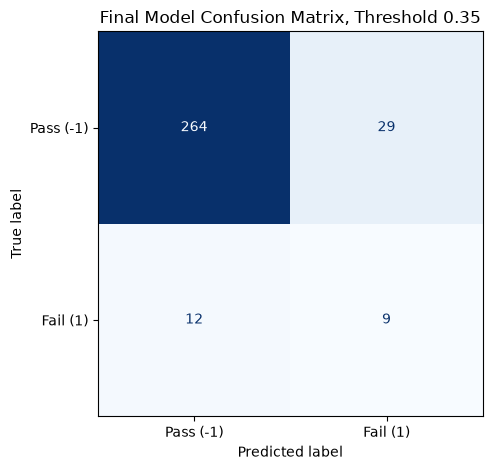

{'model': 'RF + SelectKBest tuned threshold 0.35',
 'accuracy': 0.8694267515923567,
 'balanced_accuracy': 0.6647976596782057,
 'fail_precision': 0.23684210526315788,
 'fail_recall': 0.42857142857142855,
 'fail_f1': 0.3050847457627119,
 'roc_auc': 0.7739314155696407,
 'pr_auc': 0.2835000855202607}

In [7]:
final_model = clone(rf_selectk_tuned_pipeline)
final_model.fit(X_train, y_train)

final_oof_fail_proba = get_oof_fail_probabilities(
    rf_selectk_tuned_pipeline,
    X_train,
    y_train,
    tracking_cv,
)
final_threshold_results = evaluate_thresholds(
    y_train,
    final_oof_fail_proba,
    thresholds,
)
final_threshold_results.to_csv(threshold_analysis_path, index=False)

final_best_threshold = select_best_threshold(final_threshold_results)["threshold"]
final_test_fail_proba = get_fail_probabilities(final_model, X_test)
final_test_pred = np.where(final_test_fail_proba >= final_best_threshold, 1, -1)
final_test_metrics = summarize_model(
    f"RF + SelectKBest tuned threshold {final_best_threshold:.2f}",
    y_test,
    final_test_pred,
    final_test_fail_proba,
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_pred,
    labels=[-1, 1],
    display_labels=["Pass (-1)", "Fail (1)"],
    cmap="Blues",
    colorbar=False,
)
plt.title(f"Final Model Confusion Matrix, Threshold {final_best_threshold:.2f}")
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=150)
plt.show()

final_test_metrics

In [8]:
uci_reproduction_comparison = pd.DataFrame([
    {
        "method": "UCI F-test baseline",
        "ber_mean_percent": 33.50,
        "fail_recall_mean_percent": 59.10,
        "pass_recall_mean_percent": 73.80,
    },
    {
        "method": "Approx F-test reproduction",
        "ber_mean_percent": 49.41,
        "fail_recall_mean_percent": 2.00,
        "pass_recall_mean_percent": 99.18,
    },
])
uci_reproduction_comparison.to_csv(uci_comparison_path, index=False)
uci_reproduction_comparison

,method,ber_mean_percent,fail_recall_mean_percent,pass_recall_mean_percent
0,UCI F-test baseline,33.50,59.1,73.80
1,Approx F-test reproduction,49.41,2.0,99.18


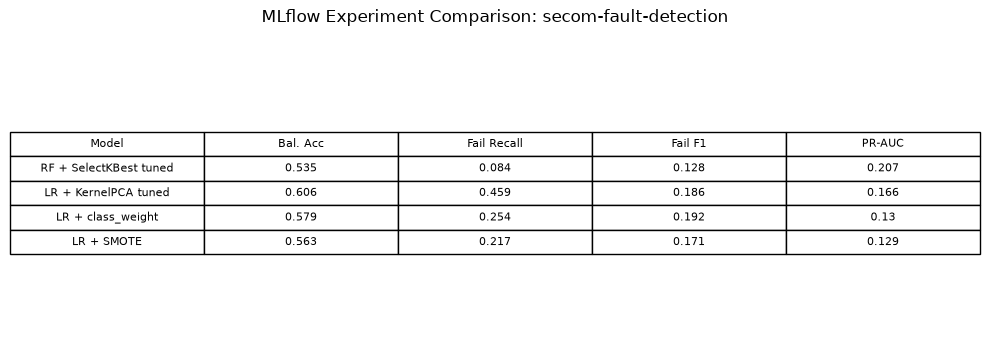

WindowsPath('E:/SECOM_Dataset_proj/reports/figures/mlflow_experiment_comparison.png')

In [9]:
comparison_for_image = model_comparison[[
    "model",
    "balanced_accuracy_mean",
    "fail_recall_mean",
    "fail_f1_mean",
    "pr_auc_mean",
]].copy()
comparison_for_image = comparison_for_image.sort_values("pr_auc_mean", ascending=False)

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.axis("off")
table = ax.table(
    cellText=comparison_for_image.round(3).values,
    colLabels=["Model", "Bal. Acc", "Fail Recall", "Fail F1", "PR-AUC"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)
ax.set_title("MLflow Experiment Comparison: secom-fault-detection", pad=18)
plt.tight_layout()
plt.savefig(experiment_comparison_image_path, dpi=150)
plt.show()

experiment_comparison_image_path

## 5. MLflow Logging

One run is logged per model configuration. The final Random Forest run also logs the fitted sklearn pipeline using the MLflow 3.x `name=` model-logging argument.

In [10]:
shared_artifacts = [
    model_comparison_path,
    uci_comparison_path,
]
final_artifacts = [
    model_comparison_path,
    threshold_analysis_path,
    uci_comparison_path,
    confusion_matrix_path,
    experiment_comparison_image_path,
]

for model_name, config in model_configs.items():
    row = tracking_cv_summary.loc[model_name]
    metrics = {
        "balanced_accuracy_mean": row["balanced_accuracy_mean"],
        "balanced_accuracy_std": row["balanced_accuracy_std"],
        "fail_recall_mean": row["fail_recall_mean"],
        "fail_recall_std": row["fail_recall_std"],
        "fail_f1_mean": row["fail_f1_mean"],
        "fail_f1_std": row["fail_f1_std"],
        "roc_auc_mean": row["roc_auc_mean"],
        "average_precision_mean": row["pr_auc_mean"],
        "ber_mean": row["ber_mean"],
        "ber_std": row["ber_std"],
    }

    if model_name == "RF + SelectKBest tuned":
        metrics.update({
            "test_fail_precision": final_test_metrics["fail_precision"],
            "test_fail_recall": final_test_metrics["fail_recall"],
            "test_fail_f1": final_test_metrics["fail_f1"],
            "test_average_precision": final_test_metrics["pr_auc"],
            "selected_threshold": final_best_threshold,
        })
        artifacts = final_artifacts
        sklearn_model = final_model
    else:
        artifacts = shared_artifacts
        sklearn_model = None

    log_model_run(
        run_name=model_name,
        params=config["params"],
        metrics=metrics,
        artifact_paths=artifacts,
        sklearn_model=sklearn_model,
        model_name="fitted_pipeline",
    )

print("Logged MLflow runs.")

2026/06/22 20:21:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged MLflow runs.


## 6. Experiment Evidence

The local experiment can be opened from the project root with:

```powershell
$env:MLFLOW_ALLOW_FILE_STORE = "true"
.\.venv\Scripts\python.exe -m mlflow ui --backend-store-uri file:.\mlruns --port 5000
```

Then open `http://127.0.0.1:5000` in a browser.

In [11]:
client = MlflowClient()
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["attributes.start_time DESC"],
)

mlflow_run_summary = pd.DataFrame([
    {
        "run_name": run.info.run_name,
        "run_id": run.info.run_id,
        "fail_recall_mean": run.data.metrics.get("fail_recall_mean"),
        "fail_f1_mean": run.data.metrics.get("fail_f1_mean"),
        "average_precision_mean": run.data.metrics.get("average_precision_mean"),
    }
    for run in runs
])

mlflow_run_summary.head(10)

,run_name,run_id,fail_recall_mean,fail_f1_mean,average_precision_mean
0,LR + KernelPCA tuned,753cd8ff9c7349dda5b362ca25f1702e,0.458554,0.185606,0.166252
1,RF + SelectKBest tuned,0a901dbeffc946c9a0a6297e14c6bcdd,0.083774,0.127993,0.207309
2,LR + SMOTE,a367a241bd2c48e7a4df495c3f44bc53,0.217372,0.171470,0.128577
3,LR + class_weight,a5a2d994f00c4d61964ad38cf9cc58e3,0.253968,0.192111,0.130104
